# TensorRT FP32 profiling — KITTI / VOC YOLOv8n

对现有 `8n_float32_fp32.engine` 和 `voc_8n_best_fp32.engine` 做阶段拆解、TensorRT 融合层排名，以及 **Nsight Systems CPU/GPU 时间线**。

- batch=1，640×640，conf=0.25，IoU=0.70；30 次 warmup、100 次测量；输入为内存中预加载的 BGR 图片。
- E2E：CPU letterbox → H2D uint8 → GPU 排布/类型转换/归一化 → D2D + TensorRT CUDA Graph → NMS → 框坐标还原/Results → GPU 完成等待。
- 不含读盘/解码、加载模型、初始化、绘图和检测结果导出到 CPU。
- **阶段拆解**为 GPU 阶段增加同步，测得可加和的诊断耗时；会改变调度。各阶段 P95 不可加和。
- **逐层 profiling**对原 engine 创建独立 context，使用带逐层 CUDA events 的 CUDA Graph；同一张图片重复 100 次。事件本身带来开销，数值用于热点排名，不能替代 baseline 延迟。
- **Nsight 时间线**保留 Ultralytics 异步和 CUDA Graph 路径，无阶段额外同步，捕获 warmup 后的执行。NVTX CPU 区间表示主机执行/提交耗时；GPU 时长查看 CUDA 行。节点级采集也有开销。

默认读取本次已经采集的结果；将 `RUN_AGAIN=True` 可重新完整 profiling。
Ultralytics 自带的阶段计时器会在阶段边界同步 GPU；时间线保留这些同步，并标记为 `Framework_GPU_sync`（灰色）。

In [1]:
from pathlib import Path
import sys, json
from IPython.display import display, Markdown, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'original').is_dir())
sys.path.insert(0, str(ROOT / 'PTQ'))
from profiling_tools import OUT, measure, capture, export_stats, show_summary, plot_timelines, write_report, find_nsys
RUN_AGAIN = False
ITERATIONS = 100
print('Python:', sys.executable)
print('Nsight Systems:', find_nsys())
print('Output:', OUT)
print('Nsight GUI:', find_nsys().parents[1] / 'host-windows-x64/nsys-ui.exe')


Python: C:\Users\dxu1\.conda\envs\notebook-env\python.exe


Nsight Systems: C:\Users\dxu1\AppData\Local\NVIDIA\NsightSystemsPortable\ProgramFiles64Folder\NVIDIA Corporation\Nsight Systems 2026.5.1\target-windows-x64\nsys.exe
Output: C:\Users\dxu1\Desktop\Dissertation\PTQ\profiling_results


Nsight GUI: C:\Users\dxu1\AppData\Local\NVIDIA\NsightSystemsPortable\ProgramFiles64Folder\NVIDIA Corporation\Nsight Systems 2026.5.1\host-windows-x64\nsys-ui.exe


In [2]:
# KITTI — stages
if RUN_AGAIN or not (OUT / 'kitti_stages.json').exists():
    measure('kitti', 'stages', ITERATIONS)
data = json.loads((OUT / 'kitti_stages.json').read_text(encoding='utf-8'))
print(data['e2e'])


{'mean_ms': 4.3828289792872965, 'median_ms': 4.247299977578223, 'p95_ms': 4.911074915435165, 'samples': 100}


In [3]:
# VOC — stages
if RUN_AGAIN or not (OUT / 'voc_stages.json').exists():
    measure('voc', 'stages', ITERATIONS)
data = json.loads((OUT / 'voc_stages.json').read_text(encoding='utf-8'))
print(data['e2e'])


{'mean_ms': 4.895006995648146, 'median_ms': 4.664549953304231, 'p95_ms': 6.024979893118143, 'samples': 100}


In [4]:
# KITTI — layers
if RUN_AGAIN or not (OUT / 'kitti_layers.json').exists():
    measure('kitti', 'layers', ITERATIONS)
data = json.loads((OUT / 'kitti_layers.json').read_text(encoding='utf-8'))
print(data['method'])
print('Fused layers:', len(data['layers']))
print('Slowest:', data['layers'][0])


IProfiler, separate context, CUDA Graph replay with per-layer CUDA events
Fused layers: 227
Slowest: {'layer': '/model.22/cv2.0/cv2.0.0/conv/Conv || /model.22/cv3.0/cv3.0.0/conv/Conv', 'mean_ms': 0.07272448107600211, 'median_ms': 0.06860800087451935, 'p95_ms': 0.09318400174379349, 'samples': 100, 'share_pct': 2.061926966783601}


In [5]:
# VOC — layers
if RUN_AGAIN or not (OUT / 'voc_layers.json').exists():
    measure('voc', 'layers', ITERATIONS)
data = json.loads((OUT / 'voc_layers.json').read_text(encoding='utf-8'))
print(data['method'])
print('Fused layers:', len(data['layers']))
print('Slowest:', data['layers'][0])


IProfiler, separate context, CUDA Graph replay with per-layer CUDA events
Fused layers: 242
Slowest: {'layer': '/model.19/conv/Conv', 'mean_ms': 0.08227200008928776, 'median_ms': 0.07884799689054489, 'p95_ms': 0.10152959711849689, 'samples': 100, 'share_pct': 2.347958068463931}


In [6]:
# KITTI — Nsight Systems CUDA/NVTX timeline
if RUN_AGAIN or not (OUT / 'kitti_timeline.nsys-rep').exists():
    capture('kitti', ITERATIONS)
print('Report:', OUT / 'kitti_timeline.nsys-rep')
print(json.loads((OUT / 'kitti_timeline.json').read_text(encoding='utf-8'))['e2e'])


Report: C:\Users\dxu1\Desktop\Dissertation\PTQ\profiling_results\kitti_timeline.nsys-rep
{'mean_ms': 5.064110995735973, 'median_ms': 4.983849939890206, 'p95_ms': 6.1108400113880625, 'samples': 100}


In [7]:
# VOC — Nsight Systems CUDA/NVTX timeline
if RUN_AGAIN or not (OUT / 'voc_timeline.nsys-rep').exists():
    capture('voc', ITERATIONS)
print('Report:', OUT / 'voc_timeline.nsys-rep')
print(json.loads((OUT / 'voc_timeline.json').read_text(encoding='utf-8'))['e2e'])


Report: C:\Users\dxu1\Desktop\Dissertation\PTQ\profiling_results\voc_timeline.nsys-rep
{'mean_ms': 5.419281001668423, 'median_ms': 5.363050033338368, 'p95_ms': 6.273650121875107, 'samples': 100}


In [8]:
# Export SQLite and NVTX / kernel / CUDA API / memory-copy CSV reports
for key in ['kitti', 'voc']:
    if RUN_AGAIN or not (OUT / f'{key}_stats_nvtx_gpu_proj_sum.csv').exists():
        export_stats(key)
    print(key, 'SQLite + 6 CSV reports available')


kitti SQLite + 6 CSV reports available
voc SQLite + 6 CSV reports available


In [9]:
# E2E stage mean/median/P95 and top 10 TensorRT fused layers
stage_rows = show_summary()


Model,Stage,Mean (ms),Median (ms),P95 (ms),Mean share (%)
kitti,01_CPU_letterbox,0.4775,0.4685,0.5339,10.9
kitti,02_CPU_tensor_view,0.0113,0.0106,0.0151,0.3
kitti,03_H2D_uint8,0.2193,0.2104,0.2611,5.0
kitti,04_GPU_layout_cast_normalize,0.1482,0.1416,0.1664,3.4
kitti,05_TensorRT_backend_D2D_and_graph,2.2826,2.1248,2.7312,52.1
kitti,06_NMS,0.7822,0.7525,1.031,17.8
kitti,07_scale_boxes_and_Results,0.2028,0.1929,0.3026,4.6
kitti,08_final_GPU_wait,0.0124,0.0121,0.0134,0.3
kitti,09_framework_and_instrumentation_overhead,0.2465,0.2346,0.314,5.6
voc,01_CPU_letterbox,0.6006,0.5901,0.7758,12.3


kitti IProfiler, separate context, CUDA Graph replay with per-layer CUDA events | profiler overhead included


Rank,TensorRT fused layer,Mean (ms),P95 (ms),Layer time share (%)
1,/model.22/cv2.0/cv2.0.0/conv/Conv || /model.22/cv3.0/cv3.0.0/conv/Conv,0.0727,0.0932,2.06
2,/model.7/conv/Conv,0.0617,0.081,1.75
3,/model.22/cv2.0/cv2.0.1/conv/Conv,0.0592,0.0768,1.68
4,/model.22/cv2.1/cv2.1.0/conv/Conv || /model.22/cv3.1/cv3.1.0/conv/Conv,0.0589,0.0799,1.67
5,/model.1/conv/Conv,0.0583,0.0717,1.65
6,__myl_MoveNegExpAddDivMul_myl5_0,0.0563,0.0563,1.6
7,/model.22/cv2.2/cv2.2.0/conv/Conv || /model.22/cv3.2/cv3.2.0/conv/Conv,0.0558,0.0737,1.58
8,/model.22/cv3.0/cv3.0.1/conv/Conv,0.0555,0.0717,1.57
9,/model.19/conv/Conv,0.053,0.0707,1.5
10,/model.0/conv/Conv,0.0529,0.0543,1.5


voc IProfiler, separate context, CUDA Graph replay with per-layer CUDA events | profiler overhead included


Rank,TensorRT fused layer,Mean (ms),P95 (ms),Layer time share (%)
1,/model.19/conv/Conv,0.0823,0.1015,2.35
2,/model.22/cv2.0/cv2.0.0/conv/Conv || /model.22/cv3.0/cv3.0.0/conv/Conv,0.0717,0.084,2.05
3,/model.22/cv2.0/cv2.0.1/conv/Conv,0.0607,0.0829,1.73
4,/model.7/conv/Conv,0.0587,0.0707,1.68
5,/model.22/cv2.1/cv2.1.0/conv/Conv || /model.22/cv3.1/cv3.1.0/conv/Conv,0.0584,0.0707,1.67
6,/model.1/conv/Conv,0.0573,0.0645,1.64
7,/model.21/cv2/conv/Conv,0.0568,0.0799,1.62
8,__myl_MoveNegExpAddDivMul_myl5_0,0.0563,0.0563,1.61
9,/model.22/cv2.2/cv2.2.0/conv/Conv || /model.22/cv3.2/cv3.2.0/conv/Conv,0.0552,0.0656,1.58
10,/model.22/cv3.0/cv3.0.1/conv/Conv,0.0542,0.0635,1.55


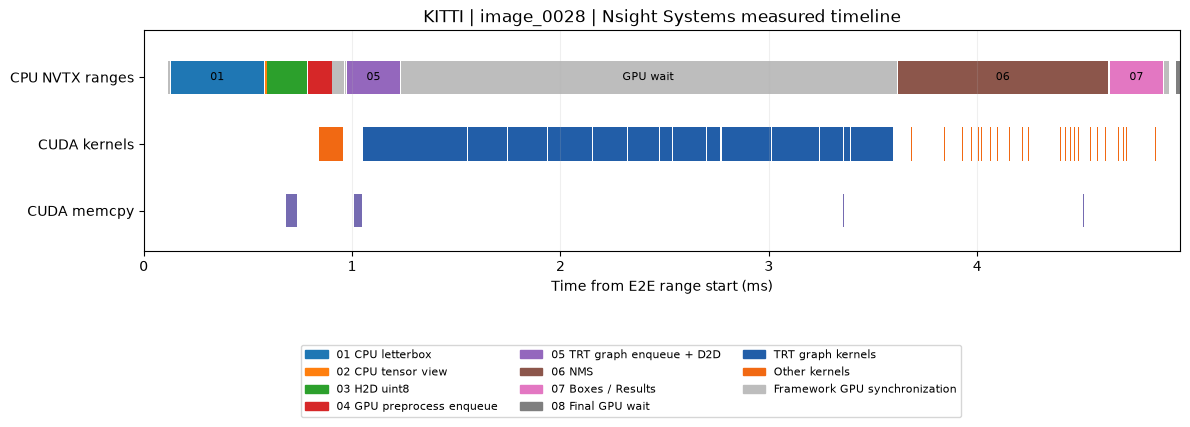

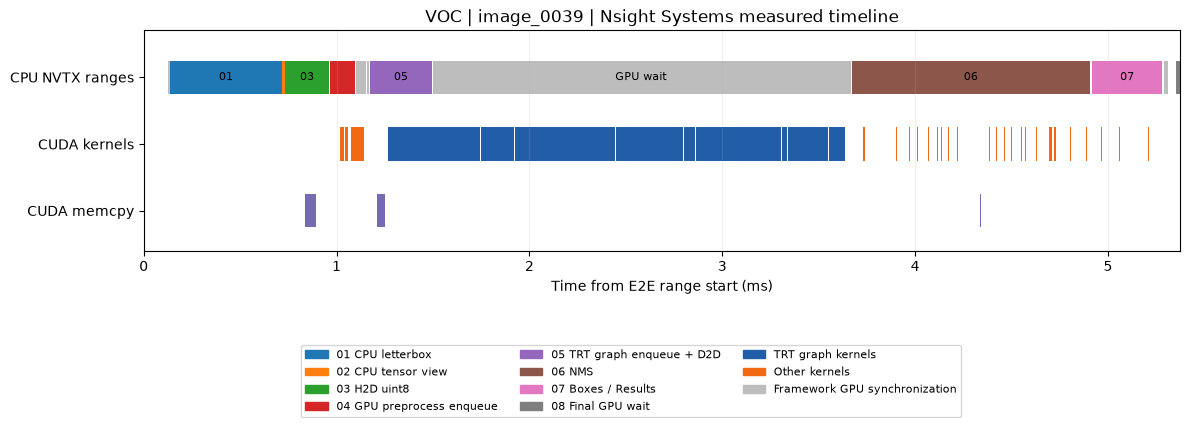

Report: C:\Users\dxu1\Desktop\Dissertation\PTQ\profiling_results\profiling_report.md
Figures: PNG, SVG and PDF in C:\Users\dxu1\Desktop\Dissertation\PTQ\profiling_results


In [10]:
# Actual Nsight SQLite timestamps, representative frame nearest median
# Blue: TensorRT graph kernels; orange: other CUDA kernels; purple: memcpy
%matplotlib inline
plot_timelines()
report = write_report()
print('Report:', report)
print('Figures: PNG, SVG and PDF in', OUT)


## 在 Nsight Systems GUI 查看

1. 启动 `nsys-ui.exe`（配置 cell 显示工具位置；同级上层的 `host-windows-x64` 下是 GUI）。
2. 打开 `profiling_results/kitti_timeline.nsys-rep` 或 `voc_timeline.nsys-rep`。
3. 展开 CPU 线程的 **NVTX** 与 **CUDA HW / Streams** 行，搜索 `E2E/`，选中中间的一张图并缩放。
4. 查看 `03_H2D_uint8`、`04_GPU_layout_cast_normalize`、`05_TensorRT_backend_D2D_and_graph`、`06_NMS`。
5. CPU 的 `05` 只覆盖提交过程；TensorRT 实际执行在 GPU kernel 行。CUDA Graph 内核按节点捕获，`nvtx-precapture` 保存捕获前的 NVTX 注释。
6. 逐层热点见上表及 `*_layers.csv`；`*_stats_cuda_gpu_kern_sum.csv` 是 **kernel 名称聚合**，一个 kernel 名可能被多个 TensorRT 层使用。

原 engine 的 profiling verbosity 是 `LAYER_NAMES_ONLY`。可以获取融合层名字和耗时；要查看详细张量类型/形状/tactic，需要重新构建 `DETAILED` engine。本 notebook 测的是原 engine。

官方文档：[Nsight Systems User Guide](https://docs.nvidia.com/nsight-systems/UserGuide/index.html) · [TensorRT IExecutionContext / report_to_profiler](https://docs.nvidia.com/deeplearning/tensorrt/latest/_static/python-api/infer/Core/ExecutionContext.html)


也可在新的 cell 中执行下面代码打开一个报告：

```python
import subprocess
nsys_ui = find_nsys().parents[1] / 'host-windows-x64/nsys-ui.exe'
subprocess.Popen([str(nsys_ui), str(OUT / 'kitti_timeline.nsys-rep')])
# VOC: 将文件名改成 voc_timeline.nsys-rep
```

时间线灰色 `Framework_GPU_sync` 是 Ultralytics 自带阶段计时器的 GPU 等待，并非 CPU 空闲或额外加入的同步。

## trtexec Top 10 复核

使用 **TensorRT 11.3.0.99 官方 trtexec**，从原始 Ultralytics engine 中只去除元数据头，未重新构建。
输入与前面的 Python IProfiler 使用同一张代表图片，按相同 GPU 预处理方式保存原始 FP32 数据。

- 每个模型重复 3 次，交替运行；每次启动前冷却到 **≤65°C**。
- batch=1，640×640，单推理流；CUDA Graph 开启；计时循环排除 H2D/D2H；spin wait 开启。
- warmup=1000 ms；正常测试和独立逐层 profiling 各至少 15 秒。
- TensorRT 11.3 默认开启 CUDA Graph、禁用数据传输并独立运行 profiling，已核对本机 `--help` 和实际运行日志。
- 下表 Mean ± SD 是 **3 次运行均值的平均值 ± 运行间样本标准差**；Top 10 按该平均值排序。
- `exportProfile` 输出每层 mean/median，**不输出逐层 P95**。正常测试的 GPU Compute P95 与逐层 P95 是不同指标。
- GPU 频率未锁定。初次连续测试出现温升和频率下降，原始记录 `*_runN_*` 保留用于追溯；复核表采用 `*_cooled_runN_*`。

VOC 另有 `*_nograph_check_*` 关闭 CUDA Graph 的诊断对照，用于检查 Myelin 子图计时，不能混入 CUDA Graph 测量平均值。


In [ ]:
from trtexec_recheck import OUT as TRT_OUT, TRTEXEC, prepare, run as trtexec_run, analyze, show_comparison
RECHECK_AGAIN = False
print('trtexec:', TRTEXEC)
print('Outputs:', TRT_OUT)
if RECHECK_AGAIN:
    for key in ['kitti', 'voc']:
        prepare(key)
    trtexec_run('voc', 1, family='nograph_check', no_graph=True)
    for repeat in range(1, 4):
        for key in ['kitti', 'voc']:
            trtexec_run(key, repeat, family='cooled')
comparison = analyze()
for key, value in comparison['models'].items():
    print(key.upper(), 'Top10 overlap:', value['Top10_overlap_with_python'], '/ 10')
    for row in value['normal_benchmarks']:
        print('Run', row['run'], 'Normal GPU compute:',
              'mean=', round(row['GPU_compute_mean_ms'], 4),
              'median=', round(row['GPU_compute_median_ms'], 4),
              'P95=', round(row['GPU_compute_P95_ms'], 4), 'ms')


In [ ]:
# trtexec Top 20 and original Python ranks; Mean ± SD across 3 runs
comparison = show_comparison()
print('Full report:', TRT_OUT / 'comparison.md')
print('Top20 CSV:', TRT_OUT / 'kitti_top20.csv', TRT_OUT / 'voc_top20.csv')
